In [216]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 


In [217]:
path = r"C:\Users\rawat\Downloads\data.csv"

dataframe = pd.read_csv(path,encoding_errors='ignore')


In [218]:
# E Commerce Data 
dataframe['StockCode'] = dataframe['StockCode'].str.replace('[\D]','',regex=True) # removing any alphabets from the stockcode 

dataframe['InvoiceDate'] = dataframe['InvoiceDate'].replace('[/]','-',regex=True) # standardizing the dateformat 

dataframe['InvoiceDate'] = pd.to_datetime(dataframe['InvoiceDate'])
pd.options.display.float_format = '{:.2f}'.format



<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\rawat\AppData\Local\Temp\ipykernel_716\606113990.py:2: SyntaxWarning: invalid escape sequence '\D'
  dataframe['StockCode'] = dataframe['StockCode'].str.replace('[\D]','',regex=True) # removing any alphabets from the stockcode


within 1 STD : 94.45%
within 2 STD : 96.45%
within 3 STD : 98.04%


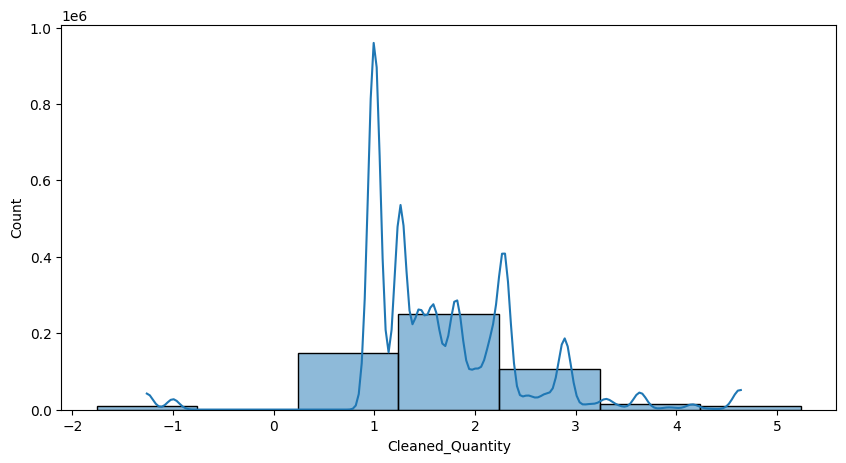

99th Percentile (Upper Boundary): 100.0
1st Percentile (Lower Boundary): -2.0
Total Outliers Found: 9995


(np.float64(119769.1600306859), np.float64(2.9522926072926166))

In [219]:
# Data distribution based on 1,2,3 STD

dataframe['Cleaned_Quantity'] = np.cbrt(dataframe['Quantity']) # squash the distance between median and outliers  # handles negative values does not remove or make them positive but pull that extreme value close to center 

upper_range = dataframe['Cleaned_Quantity'].quantile(0.99) # 99th quantile value = 100
lower_range = dataframe['Cleaned_Quantity'].quantile(0.01) # 0.01th quantile value = -2 

dataframe['Cleaned_Quantity'] = dataframe['Cleaned_Quantity'].clip(lower=lower_range,upper=upper_range) 
# new column created so that original data is safe for any further financial process and new data is already clipped by upper and lower range

q3 = dataframe['Cleaned_Quantity'].quantile(.75)
q2 = dataframe['Cleaned_Quantity'].quantile(.50)
q1 = dataframe['Cleaned_Quantity'].quantile(.25)

centrality = (q3-q2)-(q2-q1)/(q3-q1)  
skew = dataframe['Cleaned_Quantity'].skew()
outliers_present = dataframe['Cleaned_Quantity'].std()/(q3-q1)
std = dataframe['Cleaned_Quantity'].std()
iqr = q3-q1


mean = dataframe['Cleaned_Quantity'].mean()
std = dataframe['Cleaned_Quantity'].std()

# for calculating how much of our data fits in 1st,2nd,3rd STD we do the below calculation where we get the range of our 1st 2nd 3rd STD by multiplying 1,2,3 with STD and adding or subtracting for upper or lower range
for i in [1,2,3]:
    lower = mean -(i*std)
    upper = mean +(i+std)

    withinbound = dataframe[(dataframe['Cleaned_Quantity']>=lower) & (dataframe['Cleaned_Quantity']<=upper)]
    percentage = (len(withinbound)/len(dataframe))*100

    print(f'within {i} STD : {percentage:.2f}%')

plt.figure(figsize=(10,5))
sns.histplot(dataframe['Cleaned_Quantity'],kde=True,discrete=True) 
plt.show()

# 1. Calculate the cut-off points
upper_limit = dataframe['Quantity'].quantile(0.99)
lower_limit = dataframe['Quantity'].quantile(0.01)

# 2. Flag the outliers
outliers = dataframe[(dataframe['Quantity'] > upper_limit) | (dataframe['Quantity'] < lower_limit)]

print(f"99th Percentile (Upper Boundary): {upper_limit}")
print(f"1st Percentile (Lower Boundary): {lower_limit}")
print(f"Total Outliers Found: {len(outliers)}")

# since we have quite a lot of spikes it suggests that the data is leptokurtic 
dataframe['Quantity'].kurtosis(),dataframe['Cleaned_Quantity'].kurtosis()

In [220]:
pd.options.display.float_format = '{:.2f}'.format
dataframe = round(dataframe,2)
dataframe

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cleaned_Quantity
0,536365,85123,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,1.82
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,1.82
2,536365,84406,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,2.00
3,536365,84029,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,1.82
4,536365,84029,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,1.82
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.00,France,2.29
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France,1.82
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France,1.59
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France,1.59


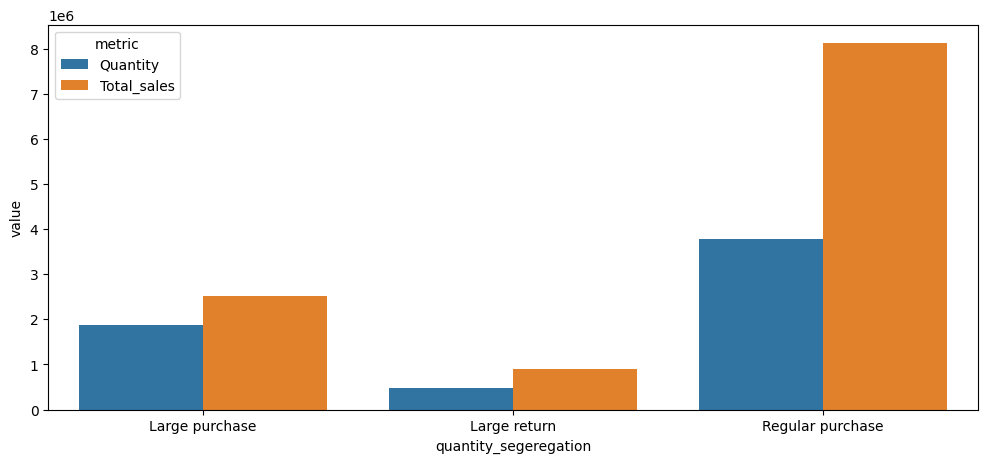

In [221]:
dataframe['zscore'] = round((dataframe['Cleaned_Quantity']-dataframe['Cleaned_Quantity'].mean())/ dataframe['Cleaned_Quantity'].std(),2)

condition = [(dataframe['zscore']<=-3),
             (dataframe['zscore']>=3)]

label = ['Large return','Large purchase']

dataframe['quantity_segeregation'] = np.select(condlist=condition,choicelist=label,default='Regular purchase')

mask = dataframe['quantity_segeregation']=='Large return'

dataframe.loc[mask,'Quantity'] = dataframe.loc[mask,'Quantity'].abs()
dataframe.loc[mask,'UnitPrice'] = dataframe.loc[mask,'UnitPrice'].abs()

dataframe['Total_sales'] = round(dataframe['Quantity']*dataframe['UnitPrice'],2)

sales_figure = dataframe.groupby('quantity_segeregation')[['Quantity','Total_sales']].sum().reset_index()

sales_fig = sales_figure.melt(id_vars='quantity_segeregation',value_vars=['Quantity','Total_sales'],value_name='value',var_name='metric')

plt.figure(figsize=(12,5))
sns.barplot(data=sales_fig, x='quantity_segeregation', y='value', hue='metric')
plt.show()

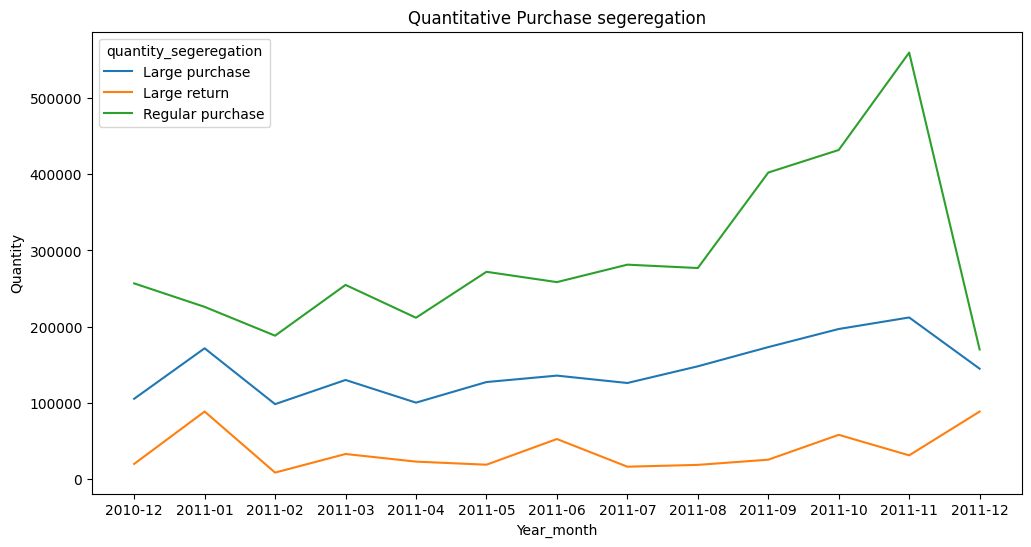

In [222]:
dataframe['Rolling_Quantity_7d'] = dataframe['Cleaned_Quantity'].rolling(window=7).mean()
dataframe['Year_month'] = dataframe['InvoiceDate'].dt.strftime('%Y-%m')

quantity_over_time = dataframe.groupby(['Year_month','quantity_segeregation'])['Quantity'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=quantity_over_time,x='Year_month',y='Quantity',hue='quantity_segeregation')
plt.title('Quantitative Purchase segeregation')
plt.show()



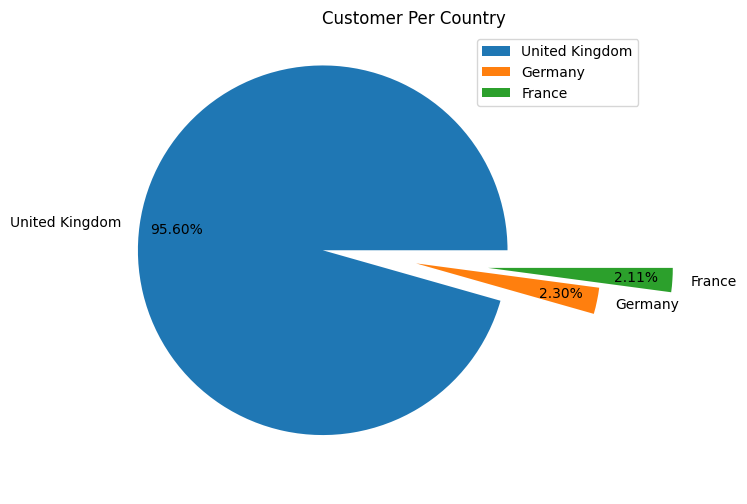

In [223]:
dataframe.isnull().sum()/len(dataframe)*100
# percentage of data missing 24% from customer_id 

datafame = dataframe['CustomerID'].fillna(np.nan)

Customer_per_country = dataframe.groupby('Country')['CustomerID'].nunique().reset_index().sort_values(by='CustomerID',ascending=False).head(3)
explode = [0.5,0.01,0.4]
plt.figure(figsize=(13,6))
plt.pie(x=Customer_per_country['CustomerID'],labels=Customer_per_country['Country'],autopct='%.2f%%',pctdistance=0.8,explode=explode)
plt.title('Customer Per Country')
plt.legend()
plt.show()

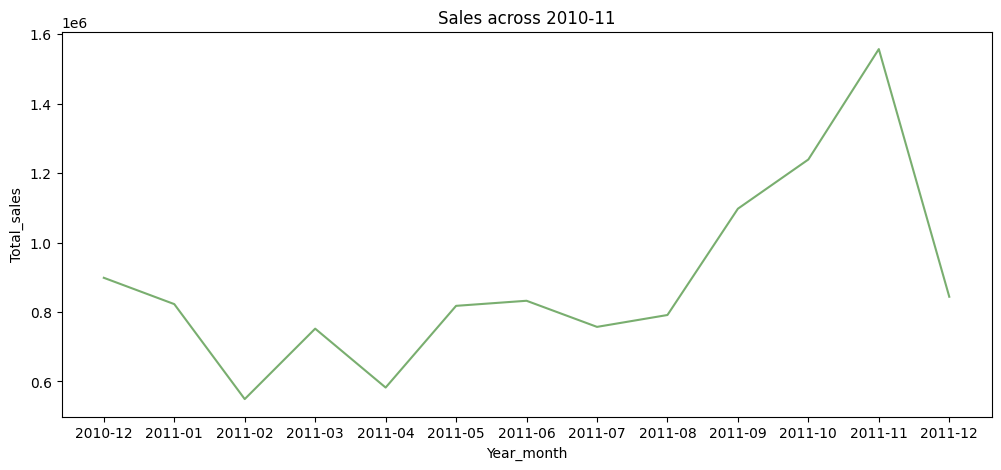

In [228]:
sales_per_year = dataframe[dataframe['quantity_segeregation']!='High Return'].groupby('Year_month')['Total_sales'].sum()

plt.figure(figsize=(12,5))

sns.lineplot(sales_per_year,color='#79AE6F')
plt.ylabel('Total_sales')
plt.title('Sales across 2010-11')
plt.show()

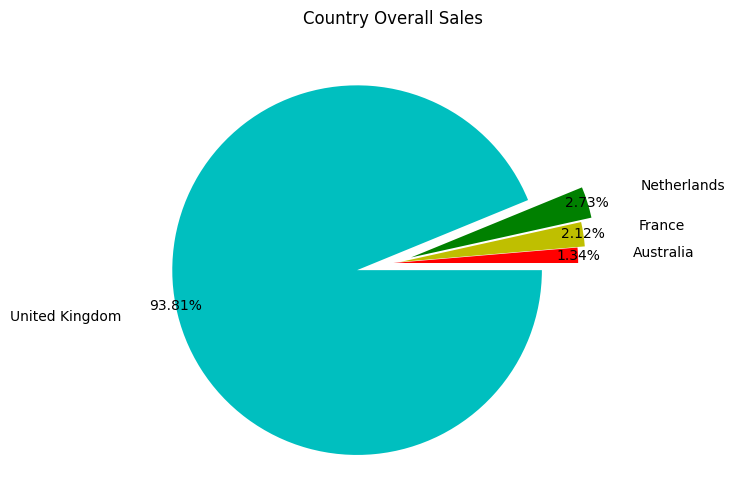

In [306]:
countries = ['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA']
# countries to choose from above 

sales = dataframe[(dataframe['Country'].isin(countries[:4])) & (dataframe['quantity_segeregation']!='High Return')]

sales_per_country = sales.groupby(['Country'])['Total_sales'].sum().reset_index()

plt.figure(figsize=(10,6))
explode = [0,.04,0.1,0.2]
plt.pie(x=sales_per_country['Total_sales'],pctdistance=True,autopct='%.2f%%',colors='rygc',explode=explode,labels=sales_per_country['Country'],labeldistance=1.3)
plt.title('Country Overall Sales')
plt.show()


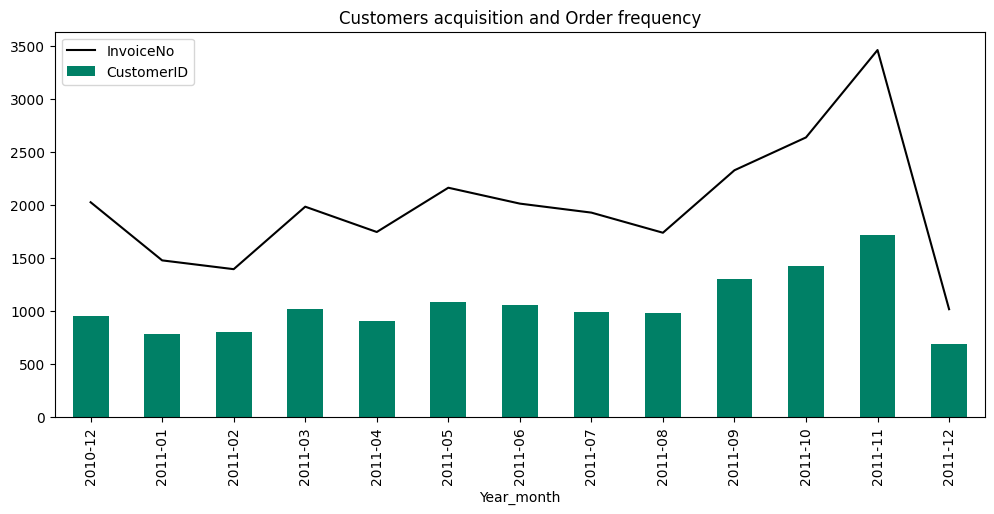

In [327]:
# Order Frequency per month 

Orders_per_month = dataframe[dataframe['quantity_segeregation']!='High Return'].groupby('Year_month')['InvoiceNo'].nunique()
customers_per_month = dataframe.groupby('Year_month')['CustomerID'].nunique()

plt.figure(figsize=(12,5))
Orders_per_month.plot(kind='line',colormap='bone')
customers_per_month.plot(kind='bar',colormap='summer')
plt.title('Customers acquisition and Order frequency')
plt.legend()
plt.show()



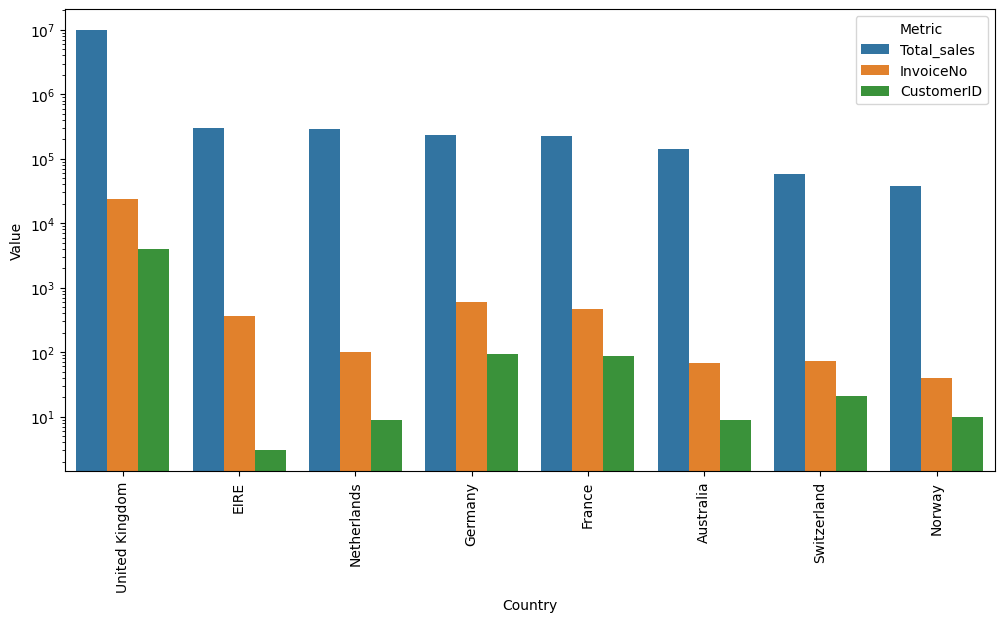

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Country', ylabel='Value'>,
 ([0, 1, 2, 3, 4, 5, 6, 7],
  [Text(0, 0, 'United Kingdom'),
   Text(1, 0, 'EIRE'),
   Text(2, 0, 'Netherlands'),
   Text(3, 0, 'Germany'),
   Text(4, 0, 'France'),
   Text(5, 0, 'Australia'),
   Text(6, 0, 'Switzerland'),
   Text(7, 0, 'Norway')]),
 None,
 None)

In [244]:
import numpy as np
import plotly.express as px

# this is for a single country
class country: 
    def __init__(self,country=None):
        self.country = country 

    def info(self):
        total_sales = dataframe['Total_sales'][dataframe['Country']==self.country].sum()- dataframe['Total_sales'][dataframe['quantity_segeregation']!='High Return'].sum()
        total_orders = dataframe['InvoiceNo'][dataframe['Country']==self.country].nunique()-dataframe['InvoiceID'][dataframe['quantity_segeregation']!='High Return'].nunique()
        total_customers = dataframe['CustomerID'][dataframe['Country']==self.country].nunique()

        return {'total_sales':total_sales,'total_orders':total_orders,'total_customers':total_customers}
    
    def sales_per_month(self):
        sales = dataframe.groupby('Year_month')['Total_sales'].sum().reset_index()
        return plt.figure(figsize=(12,6)),sns.barplot(data=sales,x='Year_month',y='Total_sales',color='#D5E7B5'),plt.title(f'Sales per month in {self.country}'),plt.show()
    
    def customer_acquisition(self):
        customers = dataframe.groupby('Year_month')['CustomerID'].nunique().reset_index()
        return plt.figure(figsize=(13,6)),sns.lineplot(data=customers,x='Year_month',y='CustomerID'),plt.title(f'Customer base Growth per month in {self.country}'),plt.show()
    
class compare_countries: # this is specifically for comparing multiple countries 
        def __init__(self,countries=None):
             self.countries = countries
        
        def compare(self):
            data = dataframe[dataframe['Country'].isin(self.countries)]
            pivot_table = data.pivot_table(index='Country',values=['Total_sales','InvoiceNo','CustomerID'],
                                       aggfunc={'Total_sales':'sum','InvoiceNo':'nunique','CustomerID':'nunique'}).reset_index().sort_values(by='Total_sales',ascending=False)

            return pivot_table
        
        def charts(self):
            data = dataframe[(dataframe['Country'].isin(self.countries)) & (dataframe['quantity_segeregation']!='High Return')]
            pivot_table = data.pivot_table(index='Country',values=['Total_sales','InvoiceNo','CustomerID'],
                                       aggfunc={'Total_sales':'sum','InvoiceNo':'nunique','CustomerID':'nunique'}).reset_index().sort_values(by='Total_sales',ascending=False)


            df_melted = pivot_table.reset_index().melt(id_vars='Country', 
                                          value_vars=['Total_sales', 'InvoiceNo', 'CustomerID'],
                                          var_name='Metric', 
                                          value_name='Value')

            return plt.figure(figsize=(12, 6)),sns.barplot(data=df_melted, x='Country', y='Value', hue='Metric'),plt.xticks(rotation=90),plt.yscale('log'),plt.show()

          
        
compare = compare_countries(countries[:8])

compare.compare()
compare.charts()


In [ ]:
# %timeit dataframe.to_dict('records')
# dataframe.to_dict('list')
# dataframe.to_dict('series')
# dataframe.to_dict('index')
# dataframe.to_dict('split')